In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

dataset_rar = "YOUR_DATASET_PATH_HERE.rar"  # Replace with the actual path to your dataset

print("Dataset found:", os.path.exists(dataset_rar))

Dataset found: True


In [ ]:
!apt-get -qq update
!apt-get -qq install -y unrar

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import os
import shutil

extract_path = "/content/plant_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path)

In [ ]:
!unrar x -o+ "YOUR_DATASET_PATH_HERE.rar" "{extract_path}/"

In [ ]:
for root, folders, files in os.walk(extract_path):

    print("Folder:", root)

    for folder in folders:
        print("  └──", folder)

    if root.count(os.sep) >= extract_path.count(os.sep) + 2:
        folders[:] = []

Folder: /content/plant_dataset
  └── Tomato_healthy
  └── Tomato_Bacterial_spot
Folder: /content/plant_dataset/Tomato_healthy
Folder: /content/plant_dataset/Tomato_Bacterial_spot


In [ ]:
import os

dataset_path = "/content/plant_dataset"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        print(folder, len(os.listdir(folder_path)))

Tomato_healthy 1591
Tomato_Bacterial_spot 2127


In [ ]:
import os
import random

dataset_path = "/content/plant_dataset/"

healthy_path = os.path.join(
    dataset_path, "Tomato_healthy"
)

diseased_path = os.path.join(
    dataset_path, "Tomato_Bacterial_spot"
)

def get_images(folder):
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

healthy_images = get_images(healthy_path)
diseased_images = get_images(diseased_path)

print("Healthy:", len(healthy_images))
print("Diseased:", len(diseased_images))

Healthy: 1591
Diseased: 2127


In [ ]:
import random

random.seed(42)

# Use all available images
selected_healthy = healthy_images.copy()
selected_diseased = diseased_images.copy()

# Shuffle the image order
random.shuffle(selected_healthy)
random.shuffle(selected_diseased)

print("Selected healthy:", len(selected_healthy))
print("Selected diseased:", len(selected_diseased))

Selected healthy: 1591
Selected diseased: 2127


In [ ]:

import numpy as np
import tensorflow as tf

from PIL import Image, UnidentifiedImageError

IMG_SIZE = 64

images = []
labels = []

def load_images(file_paths, label):

    loaded = 0
    skipped = 0

    for path in file_paths:

        try:
            with Image.open(path) as img:

                img = img.convert("RGB")

                img = img.resize(
                    (IMG_SIZE, IMG_SIZE)
                )

                img_array = np.array(
                    img,
                    dtype=np.float32
                ) / 255.0

            images.append(img_array)
            labels.append(label)

            loaded += 1

        except (UnidentifiedImageError, OSError, ValueError) as e:

            print("Skipping:", path)
            print("Reason:", e)

            skipped += 1

    print("Successfully loaded:", loaded)
    print("Skipped:", skipped)
    print()

load_images(selected_healthy, 0)

load_images(selected_diseased, 1)

X = np.array(images, dtype=np.float32)

y = np.array(labels, dtype=np.int32)

print("Image shape:", X.shape)
print("Label shape:", y.shape)
print("Healthy images:", np.sum(y == 0))
print("Diseased images:", np.sum(y == 1))

Successfully loaded: 1591
Skipped: 0

Successfully loaded: 2127
Skipped: 0

Image shape: (3718, 64, 64, 3)
Label shape: (3718,)
Healthy images: 1591
Diseased images: 2127


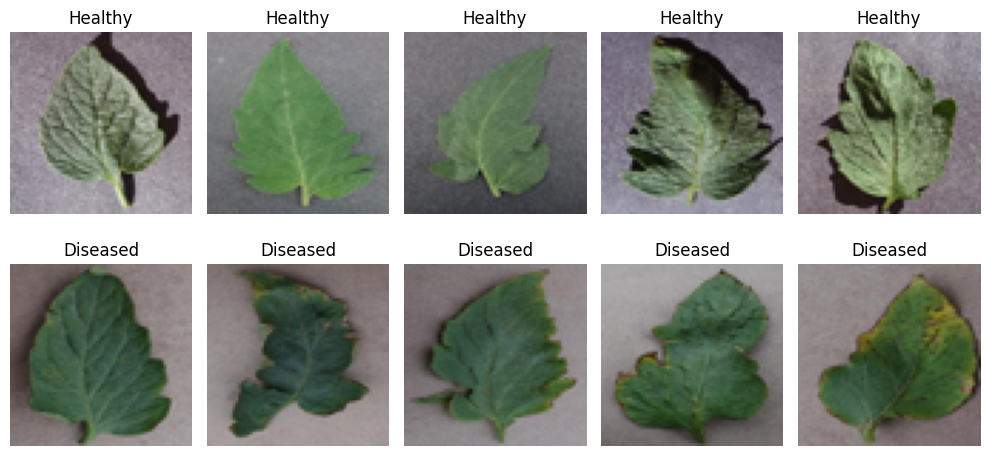

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

healthy_indices = np.where(y == 0)[0][:5]
diseased_indices = np.where(y == 1)[0][:5]

selected_indices = np.concatenate([
    healthy_indices,
    diseased_indices
])

for i, index in enumerate(selected_indices):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X[index])

    plt.title(
        "Healthy" if y[index] == 0 else "Diseased"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split

# Keep 15% completely untouched for final testing
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("Development images:", len(X_dev))
print("Testing images:", len(X_test))

Development images: 3160
Testing images: 558


In [ ]:
def create_model():

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),

        tf.keras.layers.Conv2D(
            16,
            (3, 3),
            activation="relu"
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_index, val_index) in enumerate(
    kfold.split(X_dev, y_dev),
    start=1
):
    X_fold_train = X_dev[train_index]
    y_fold_train = y_dev[train_index]

    X_fold_val = X_dev[val_index]
    y_fold_val = y_dev[val_index]

    print(f"Fold {fold}")
    print("Training:", len(X_fold_train))
    print("Validation:", len(X_fold_val))

Fold 1
Training: 2528
Validation: 632
Fold 2
Training: 2528
Validation: 632
Fold 3
Training: 2528
Validation: 632
Fold 4
Training: 2528
Validation: 632
Fold 5
Training: 2528
Validation: 632


In [ ]:
fold_accuracies = []
fold_losses = []
fold_histories = []
best_epochs = []

for fold, (train_index, val_index) in enumerate(
    kfold.split(X_dev, y_dev),
    start=1
):

    print(f"\n========== FOLD {fold} ==========\n")

    X_fold_train = X_dev[train_index]
    y_fold_train = y_dev[train_index]

    X_fold_val = X_dev[val_index]
    y_fold_val = y_dev[val_index]

    print("Training images:", len(X_fold_train))
    print("Validation images:", len(X_fold_val))

    # Calculate class weights for THIS fold
    classes = np.unique(y_fold_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_fold_train
    )

    class_weights = {
        int(cls): float(weight)
        for cls, weight in zip(classes, weights)
    }

    print("Class weights:", class_weights)

    # Fresh model for every fold
    model = create_model()

    # Fresh EarlyStopping for every fold
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_fold_train,
        y_fold_train,

        validation_data=(
            X_fold_val,
            y_fold_val
        ),

        epochs=30,
        batch_size=32,

        class_weight=class_weights,

        callbacks=[early_stopping],

        verbose=1
    )

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    best_epochs.append(best_epoch)

    fold_histories.append(history.history)

    # Evaluate this fold
    val_loss, val_accuracy = model.evaluate(
        X_fold_val,
        y_fold_val,
        verbose=0
    )

    fold_losses.append(val_loss)
    fold_accuracies.append(val_accuracy)

    print(
        f"Fold {fold} validation accuracy:",
        val_accuracy
    )

print("Best epochs:", best_epochs)

final_epochs = int(round(np.mean(best_epochs)))

print("Average best epoch:", final_epochs)


========== FOLD 1 ==========

Training images: 2528
Validation images: 632
Class weights: {0: 1.1682070240295748, 1: 0.8741355463347165}
Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8441 - loss: 0.3502 - val_accuracy: 0.8861 - val_loss: 0.3151
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.9569 - loss: 0.1319 - val_accuracy: 0.9810 - val_loss: 0.0756
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.9759 - loss: 0.0739 - val_accuracy: 0.9810 - val_loss: 0.0531
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9858 - loss: 0.0508 - val_accuracy: 0.9747 - val_loss: 0.0693
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9885 - loss: 0.0459 - val_accuracy: 0.9858 - val_loss: 0.0436
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.9901 - loss: 0.0319 - val_accuracy: 0.9921 - val_loss: 0.0249
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9917 - loss: 0.0308 - val_acc

In [ ]:
final_model = create_model()

classes = np.unique(y_dev)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_dev
)

final_class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

final_history = final_model.fit(
    X_dev,
    y_dev,
    epochs=final_epochs,
    batch_size=32,
    class_weight=final_class_weights
)

test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.8427 - loss: 0.3452
Epoch 2/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9557 - loss: 0.1173
Epoch 3/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.9772 - loss: 0.0623
Epoch 4/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9880 - loss: 0.0398
Epoch 5/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9918 - loss: 0.0270
Epoch 6/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9899 - loss: 0.0297
Epoch 7/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9956 - loss: 0.0158
Epoch 8/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9981 - loss: 0.0108
Epoch 9/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.9972 - loss: 0.0085
Epoch 10/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9994 - loss: 0.0060
Epoch 11/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9994 - loss: 0.0044
Epoch 12/19
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accur

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Confusion Matrix:
[[237   2]
 [  2 317]]

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9916    0.9916    0.9916       239
    Diseased     0.9937    0.9937    0.9937       319

    accuracy                         0.9928       558
   macro avg     0.9927    0.9927    0.9927       558
weighted avg     0.9928    0.9928    0.9928       558



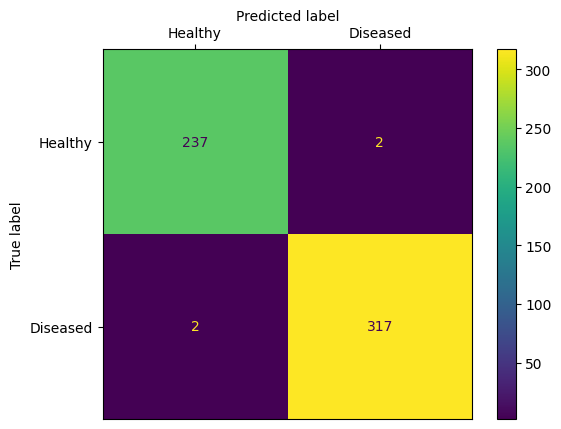

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Predictions
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# True labels
y_true = y_test.flatten().astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "Diseased"],
    digits=4
))

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Diseased"]
)

disp.plot()
disp.ax_.xaxis.tick_top()
disp.ax_.xaxis.set_label_position("top")
plt.show()

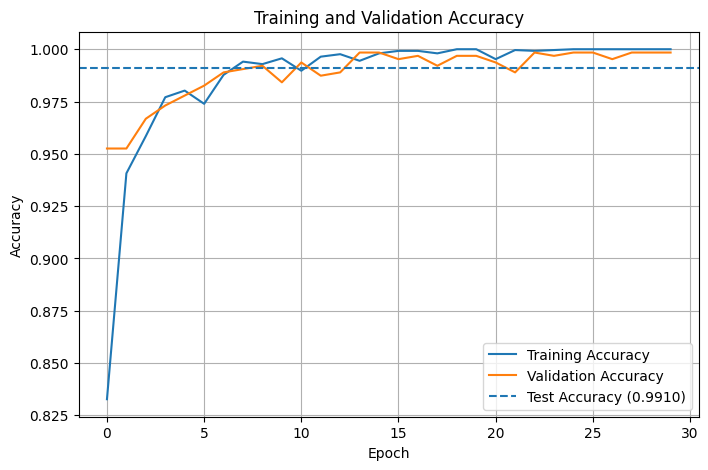

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.axhline(
    y=test_accuracy,
    linestyle="--",
    label=f"Test Accuracy ({test_accuracy:.4f})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()


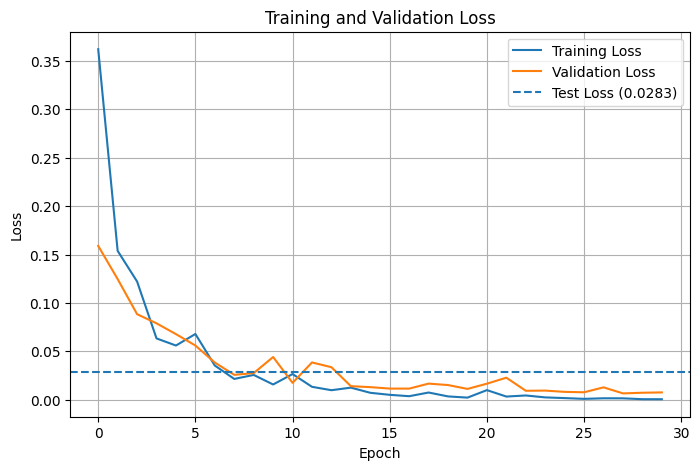

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.axhline(
    y=test_loss,
    linestyle="--",
    label=f"Test Loss ({test_loss:.4f})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
model.save("plant_disease_model.keras")

In [ ]:
import os

size = os.path.getsize("plant_disease_model.keras")
print("Model size:", size / 1024, "KB")

Model size: 2448.9794921875 KB


In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("plant_disease_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model created")

Saved artifact at '/tmp/tmphv45pwjq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor_80')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132775847536080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775845852176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775845854288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775845854864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775845850640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775847454928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775847460496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775847456848: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model created


In [ ]:
import os

size = os.path.getsize("plant_disease_model.tflite")

print("TFLite model size:", size / 1024, "KB")

TFLite model size: 808.22265625 KB


In [ ]:
import numpy as np

# Get one test image
test_image = X_test[0:1]

# Make sure datatype matches the TFLite input
test_image = test_image.astype(input_details[0]["dtype"])

# Give image to TFLite model
interpreter.set_tensor(
    input_details[0]["index"],
    test_image
)

# Run inference
interpreter.invoke()

# Get prediction
tflite_prediction = interpreter.get_tensor(
    output_details[0]["index"]
)

print("TFLite probability:", tflite_prediction[0][0])
print("True label:", y_test[0])

if tflite_prediction[0][0] >= 0.5:
    print("Prediction: Diseased")
else:
    print("Prediction: Healthy")

TFLite probability: 0.9896449
True label: 1
Prediction: Diseased


In [ ]:
keras_prediction = model.predict(X_test[0:1])

print("Keras probability:", keras_prediction[0][0])
print("TFLite probability:", tflite_prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Keras probability: 0.9896452
TFLite probability: 0.9896449


In [ ]:
tflite_preds = []

for i in range(len(X_test)):
    image = X_test[i:i+1].astype(input_details[0]["dtype"])

    interpreter.set_tensor(
        input_details[0]["index"],
        image
    )

    interpreter.invoke()

    prediction = interpreter.get_tensor(
        output_details[0]["index"]
    )[0][0]

    tflite_preds.append(prediction)

tflite_preds = np.array(tflite_preds)

tflite_classes = (tflite_preds >= 0.5).astype(int)

tflite_accuracy = np.mean(
    tflite_classes == y_test.flatten()
)

print("TFLite test accuracy:", tflite_accuracy)

TFLite test accuracy: 0.992831541218638


In [ ]:
print("Input dtype:", input_details[0]["dtype"])
print("Output dtype:", output_details[0]["dtype"])

Input dtype: <class 'numpy.float32'>
Output dtype: <class 'numpy.float32'>


In [ ]:
keras_probs = model.predict(X_test).flatten()
keras_classes = (keras_probs >= 0.5).astype(int)

keras_manual_accuracy = np.mean(
    keras_classes == y_test.flatten()
)

print("Keras manual accuracy:", keras_manual_accuracy)
print("TFLite accuracy:", tflite_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Keras manual accuracy: 0.992831541218638
TFLite accuracy: 0.992831541218638


In [ ]:
def representative_dataset():
    for i in range(min(200, len(X_train))):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quantized_tflite_model = converter.convert()

with open("plant_disease_model_int8.tflite", "wb") as f:
    f.write(quantized_tflite_model)

print("INT8 model created")

Saved artifact at '/tmp/tmpp6157phv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor_80')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132775847536080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775845852176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775845854288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775845854864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775845850640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775847454928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775847460496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132775847456848: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 model created


In [ ]:
import os

float_size = os.path.getsize(
    "plant_disease_model.tflite"
) / 1024

int8_size = os.path.getsize(
    "plant_disease_model_int8.tflite"
) / 1024

print("Float32 model:", float_size, "KB")
print("INT8 model:", int8_size, "KB")

Float32 model: 808.22265625 KB
INT8 model: 207.6015625 KB


In [ ]:
int8_interpreter = tf.lite.Interpreter(
    model_path="plant_disease_model_int8.tflite"
)

int8_interpreter.allocate_tensors()

int8_input_details = int8_interpreter.get_input_details()
int8_output_details = int8_interpreter.get_output_details()

print("Input dtype:", int8_input_details[0]["dtype"])
print("Output dtype:", int8_output_details[0]["dtype"])

print(
    "Input quantization:",
    int8_input_details[0]["quantization"]
)

print(
    "Output quantization:",
    int8_output_details[0]["quantization"]
)

Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: (0.0037216455675661564, -128)
Output quantization: (0.00390625, -128)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
print("Input dtype:", int8_input_details[0]["dtype"])
print("Input quantization:", int8_input_details[0]["quantization"])

print("Output dtype:", int8_output_details[0]["dtype"])
print("Output quantization:", int8_output_details[0]["quantization"])

Input dtype: <class 'numpy.int8'>
Input quantization: (0.0037216455675661564, -128)
Output dtype: <class 'numpy.int8'>
Output quantization: (0.00390625, -128)


In [ ]:
int8_predictions = []

input_scale, input_zero_point = \
    int8_input_details[0]["quantization"]

output_scale, output_zero_point = \
    int8_output_details[0]["quantization"]

for i in range(len(X_test)):

    image = X_test[i:i+1].astype(np.float32)

    # Float -> INT8
    quantized_image = (
        image / input_scale + input_zero_point
    )

    quantized_image = np.round(quantized_image)

    quantized_image = np.clip(
        quantized_image,
        -128,
        127
    ).astype(np.int8)

    # Give quantized image to model
    int8_interpreter.set_tensor(
        int8_input_details[0]["index"],
        quantized_image
    )

    int8_interpreter.invoke()

    # Get quantized output
    quantized_output = int8_interpreter.get_tensor(
        int8_output_details[0]["index"]
    )[0][0]

    # IMPORTANT: cast before subtracting
    probability = (
        int(quantized_output) - output_zero_point
    ) * output_scale

    int8_predictions.append(probability)

int8_predictions = np.array(int8_predictions)

int8_classes = (
    int8_predictions >= 0.5
).astype(int)

int8_accuracy = np.mean(
    int8_classes == y_test.flatten()
)

print("Keras accuracy:", keras_manual_accuracy)
print("Float32 TFLite accuracy:", tflite_accuracy)
print("INT8 TFLite accuracy:", int8_accuracy)

Keras accuracy: 0.992831541218638
Float32 TFLite accuracy: 0.992831541218638
INT8 TFLite accuracy: 0.992831541218638


In [ ]:
import os

keras_size = os.path.getsize("plant_disease_model.keras") / 1024
float_size = os.path.getsize("plant_disease_model.tflite") / 1024
int8_size = os.path.getsize("plant_disease_model_int8.tflite") / 1024

print(f"Keras model: {keras_size:.2f} KB")
print(f"Float32 TFLite model: {float_size:.2f} KB")
print(f"INT8 TFLite model: {int8_size:.2f} KB")

Keras model: 2448.98 KB
Float32 TFLite model: 808.22 KB
INT8 TFLite model: 207.60 KB


In [ ]:
model_path = "plant_disease_model_int8.tflite"
header_path = "model_data.h"

with open(model_path, "rb") as f:
    model_data = f.read()

with open(header_path, "w") as f:
    f.write("#pragma once\n\n")

    f.write("const unsigned char model_data[] = {\n")

    for i, byte in enumerate(model_data):
        if i % 12 == 0:
            f.write("  ")

        f.write(f"0x{byte:02x}")

        if i != len(model_data) - 1:
            f.write(", ")

        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write("\n};\n\n")
    f.write(f"const unsigned int model_data_len = {len(model_data)};\n")

print("Created:", header_path)
print("Model bytes:", len(model_data))

Created: model_data.h
Model bytes: 212584


In [ ]:
import numpy as np

# Pick the first test image
image = X_test[0:1].astype(np.float32)

# Get INT8 quantization parameters
input_scale, input_zero_point = \
    int8_input_details[0]["quantization"]

# Quantize exactly like we did during INT8 testing
quantized_image = (
    image / input_scale + input_zero_point
)

quantized_image = np.round(quantized_image)

quantized_image = np.clip(
    quantized_image,
    -128,
    127
).astype(np.int8)

# Flatten 64x64x3 into one long array
flat_image = quantized_image.flatten()

true_label = int(y_test[0])

with open("test_image.h", "w") as f:
    f.write("#pragma once\n")
    f.write("#include <stdint.h>\n\n")

    f.write("const int8_t test_image[] = {\n")

    for i, value in enumerate(flat_image):
        if i % 16 == 0:
            f.write("  ")

        f.write(str(int(value)))

        if i != len(flat_image) - 1:
            f.write(", ")

        if (i + 1) % 16 == 0:
            f.write("\n")

    f.write("\n};\n\n")

    f.write(
        f"const unsigned int test_image_len = {len(flat_image)};\n"
    )

    f.write(
        f"const int test_image_true_label = {true_label};\n"
    )

print("Created test_image.h")
print("Pixels:", len(flat_image))
print("True label:", true_label)
print("0 = Healthy, 1 = Diseased")

Created test_image.h
Pixels: 12288
True label: 1
0 = Healthy, 1 = Diseased
